In [1]:
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

In [2]:
%cd ../../

c:\Users\Matth\OneDrive\Documents\UMD\classes\junior year\Summer\research\R determination


C:\Users\Matth\AppData\Roaming\Python\Python312\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
import Util
import Spec1D
import Spec2D
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

C:\Users\Matth\AppData\Local\Temp\ipykernel_100880\606912246.py:15: RuntimeWarning: invalid value encountered in sqrt
  view = np.sqrt(spec2D)#Sqrt makes it more clear to see


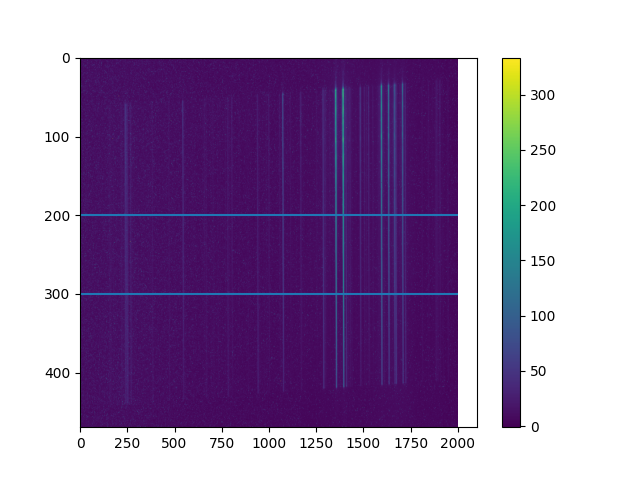

In [ ]:
linePath = "C:\\Users\\Matth\\OneDrive\\Documents\\UMD\\classes\\junior year\\Semester 2\\research\\XeHgArKr_lines.dat"
lines =  Util.createLineList(linePath, mergedLines=["Xe"], minWav=10000, maxWav=15000)

imagePath = "C:\\Users\\Matth\\OneDrive\\Documents\\UMD\\classes\\junior year\\Semester 2\\research\\step0\\drive-download-20260309T151050Z-3-001\\20250123.rimas.0060.YJ.fits"
spec2D = fits.open(imagePath)[0].data

spec2D[np.isnan(spec2D)]=-1
spec2D = Util.cropImage(spec2D, 1740, 1000, 470, 2000)
Util.flipX(spec2D)

minY = 200
maxY = 300

fig, ax = plt.subplots()
view = np.sqrt(spec2D)#Sqrt makes it more clear to see the faint and bright lines at the same time
view[np.isnan(view)]=-1
img = ax.imshow(view, vmin=np.min(view), vmax=np.max(view)) 
fig.colorbar(img)
ax.hlines([minY, maxY], 0, 2000)
ax.set_aspect("auto")

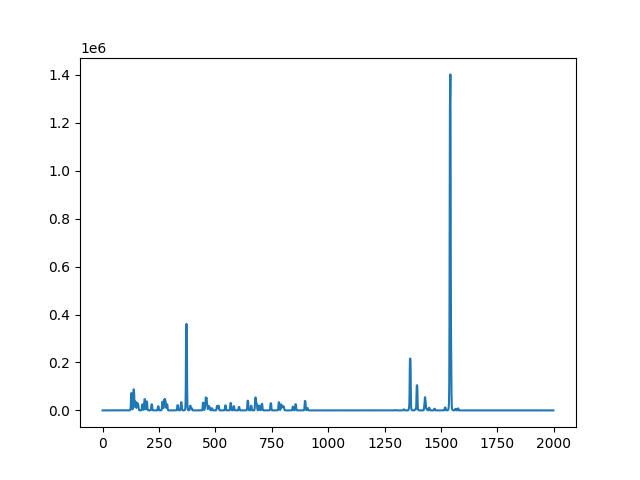

In [9]:
fig, ax = plt.subplots()
ax.plot(Spec1D.calcModel(lines, 2000, 9600, 0.3))